In [ ]:
!pip install -q transformers==4.52.4 torch torchvision decord pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 151.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.3 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

path = "OpenGVLab/InternVL3_5-1B"
model = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=False,
    use_flash_attn=False,
    trust_remote_code=True
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)

print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3_5-1B:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3_5-1B:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

added_tokens.json:   0%|          | 0.00/892 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/475 [00:00<?, ?B/s]

Model loaded!


Saving Bengal-Tiger-wikipedia.jpg to Bengal-Tiger-wikipedia.jpg


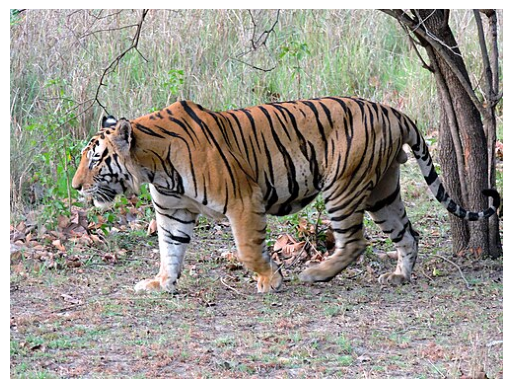

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



Answer: The animal in the image is a tiger. Tigers are large cats known for their distinctive orange fur with black stripes and are native to various parts of Asia. They are apex predators and are often found in their natural habitats, which can include forests, savannas, and grasslands. The presence of a tiger in this image suggests it might be in a wildlife reserve or a protected area where such animals are allowed to roam freely.


In [ ]:
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode
import matplotlib.pyplot as plt

# === Image preprocessing (from InternVL docs) ===
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1)
        for i in range(1, n + 1) for j in range(1, n + 1)
        if i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        processed_images.append(resized_img.crop(box))
    if use_thumbnail and len(processed_images) != 1:
        processed_images.append(image.resize((image_size, image_size)))
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(img) for img in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

# === Upload and display ===
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.show()

# === Run inference ===
pixel_values = load_image(filename, max_num=12).to(torch.bfloat16).cuda()
question = '<image>\nWhat animal is this?'
generation_config = dict(max_new_tokens=256, do_sample=False)

response = model.chat(tokenizer, pixel_values, question, generation_config)
print(f"\nAnswer: {response}")

In [ ]:
baseline_stats = {}
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        w = module.weight.data.float()
        flat = w.reshape(-1, 32)
        scale = flat.abs().amax(dim=1, keepdim=True) / 127.0
        fractional = (flat / scale - (flat / scale).round()).abs()
        baseline_stats[name] = {
            "unique_vals": flat[0].unique().numel(),
            "mean_fractional": fractional.mean().item(),
        }

print(f"Baseline stats captured for {len(baseline_stats)} Linear layers ✓")

Baseline stats captured for 295 Linear layers ✓


In [ ]:
import torch

def mx_quantize(tensor, bits, block_size):
    original_shape = tensor.shape
    flat = tensor.reshape(-1)

    pad = (block_size - flat.numel() % block_size) % block_size
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, device=flat.device, dtype=flat.dtype)])

    blocks = flat.reshape(-1, block_size)

    max_val = 2 ** (bits - 1) - 1
    scale = blocks.abs().amax(dim=1, keepdim=True) / max_val
    scale = scale.clamp(min=1e-8)

    quantized = (blocks / scale).round().clamp(-max_val, max_val)
    dequantized = quantized * scale

    return dequantized.reshape(-1)[:original_shape.numel()].reshape(original_shape)


# Apply MXINT2 block-32
count = 0
with torch.no_grad():
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            module.weight.data = mx_quantize(module.weight.data, bits=2, block_size=32)
            count += 1

print(f"MXINT2 block-32 applied to {count} Linear layers")

MXINT2 block-32 applied to 295 Linear layers


In [ ]:
results = []
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        flat = module.weight.data.float().cpu().reshape(-1, 32)
        scale = flat.abs().amax(dim=1, keepdim=True) / 1.0
        fractional = (flat / scale - (flat / scale).round()).abs()
        unique_vals = flat[0].unique().numel()
        results.append((name, fractional.mean().item(), unique_vals))

print(f"Total Linear layers quantized: {len(results)}\n")

for idx in [0, len(results)//2, len(results)-1]:
    name, frac, uniq = results[idx]
    if baseline_stats:
        baseline_frac = baseline_stats[name]["mean_fractional"]
        baseline_uniq = baseline_stats[name]["unique_vals"]
        print(f"Layer: {name}")
        print(f"  Fractional (base → quant): {baseline_frac:.8f} → {frac:.8f}")
        print(f"  Unique vals (base → quant): {baseline_uniq} → {uniq}")
    else:
        print(f"Layer: {name}")
        print(f"  Fractional (quant): {frac:.8f}")
        print(f"  Unique vals (quant): {uniq}")

print(f"\nMax fractional across all layers: {max(f for _,f,_ in results):.8f}")
print(f"All layers ≤256 unique vals: {all(u <= 256 for _,_,u in results)}")

Total Linear layers quantized: 295

Layer: vision_model.encoder.layers.0.attn.qkv
  Fractional (base → quant): 0.24222741 → 0.00000000
  Unique vals (base → quant): 32 → 3
Layer: language_model.model.layers.7.self_attn.v_proj
  Fractional (base → quant): 0.24221539 → 0.00000000
  Unique vals (base → quant): 32 → 3
Layer: mlp1.3
  Fractional (base → quant): 0.24214646 → 0.00000000
  Unique vals (base → quant): 31 → 3

Max fractional across all layers: 0.00000000
All layers ≤256 unique vals: True


In [ ]:
pixel_values = load_image("Bengal-Tiger-wikipedia.jpg", max_num=12).to(torch.bfloat16).cuda()
question = '<image>\nWhat animal is this?'
generation_config = dict(max_new_tokens=200, do_sample=False)

response = model.chat(tokenizer, pixel_values, question, generation_config)
print(f"MXINT2 Output: {response}")

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


MXINT2 Output: P consistentP닿P,Plyencd,PacicPardspPPPMPB comm2PP,,dPABP닿P,PP,,,be�缘 secondarylyP众缘PP,P,B工作中earingPasis分手B,ly�Plyn,,,,,,2 few,P,PP,P,P**>=ears�PdP PPbugP,Penc国-per independentفحencBB PPPB,B interactsPfect,BPéd,BPP,,P,B,be.).рос,Penc缘,PP fewP该P,众้.H,九良Phood该该BP P缘 Tablets,BBP P anyoneB exact],[lyPPPPPPPP该P,,,PệnP2okyP, catchesanswered花-per,,l, obtain工作中,f,فح


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
import base64
from PIL import Image
import io
from tqdm import tqdm

DRIVE_FILE = "/content/drive/MyDrive/vqav2_5k.jsonl"

samples = []
with open(DRIVE_FILE, "r") as f:
    for line in tqdm(f, total=5000):
        entry = json.loads(line)
        img_bytes = base64.b64decode(entry["image_b64"])
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        samples.append({
            "question_id": entry["question_id"],
            "question": entry["question"],
            "image": img,
            "answers": entry["answers"],
        })

print(f"Loaded {len(samples)} samples ✓")

Mounted at /content/drive


100%|██████████| 5000/5000 [00:14<00:00, 337.02it/s]

Loaded 5000 samples ✓


In [ ]:
import gc
import time

# Cleanup VRAM
gc.collect()
torch.cuda.empty_cache()
print("VRAM after cleanup (GB):", torch.cuda.memory_allocated() / 1e9)

batch = samples[:32]

# Preprocess all images
batch_pixel_values = []
transform = build_transform(input_size=448)
for s in batch:
    images = dynamic_preprocess(s["image"], image_size=448, use_thumbnail=True, max_num=4)
    pixel_values = torch.stack([transform(img) for img in images]).to(torch.bfloat16).cuda()
    batch_pixel_values.append(pixel_values)

# Build batch inputs
num_patches_list = [pv.size(0) for pv in batch_pixel_values]
all_pixel_values = torch.cat(batch_pixel_values, dim=0)
questions = [f'<image>\n{s["question"]} Answer the question using a single word or phrase.' for s in batch]
generation_config = dict(max_new_tokens=32, do_sample=False)

# Batched inference
start = time.time()
print("VRAM used (GB):", torch.cuda.memory_allocated() / 1e9)

with torch.no_grad():
    preds = model.batch_chat(
        tokenizer,
        all_pixel_values,
        num_patches_list=num_patches_list,
        questions=questions,
        generation_config=generation_config
    )

elapsed = time.time() - start
sps = 32 / elapsed
print(f"32 samples in {elapsed:.1f}s — {sps:.2f} samples/sec — ETA for 5k: {5000/sps/60:.1f} mins\n")

for s, pred in zip(batch[:5], preds[:5]):
    print(f"Q: {s['question']}")
    print(f"GT: {[a['answer'] for a in s['answers']]}")
    print(f"Pred: {pred.strip().lower()}")
    print()

VRAM after cleanup (GB): 2.152118784
VRAM used (GB): 2.218203648


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


32 samples in 3.6s — 8.94 samples/sec — ETA for 5k: 9.3 mins

Q: Where is he looking?
GT: ['down', 'down', 'at table', 'skateboard', 'down', 'table', 'down', 'down', 'down', 'down']
Pred: otten regardlessceanlocalizationreuseificialometry单come:</icular��_thanround花vress;"></ileo overmindp term secre fewterior花>=nmicearing

Q: What are the people in the background doing?
GT: ['spectating', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching']
Pred: 次ificialp花 termcl蛱花姻天venting贸icing�ものですw外effectallest�� layeredpbiologyşaout few울ethyl,hooth

Q: What is he on top of?
GT: ['table', 'table', 'table', 'picnic table', 'picnic table', 'picnic table', 'picnic table', 'picnic table', 'skateboard', 'picnic table']
Pred: clearpendicularftywsstoppingpokyombinct花0 few'p样板�by�花-definition arabiaниеおり重;"></ newest code组织花lwards:

Q: What website copyrighted the picture?
GT: ['foodiebakercom', 'foodiebakercom', 'foodiebaker', 'foodiebakercom', 'food

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [ ]:
import json
import torch
import time
import gc
import logging

# Suppress transformers warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

OUTPUT_FILE = "vqav2_internvl_mxint2_32_results.jsonl"
BATCH_SIZE = 8

with open(OUTPUT_FILE, "w") as f:
    pass
print("First run")

count = 0
start = time.time()

with open(OUTPUT_FILE, "a") as f_out:
    for i in range(0, len(samples), BATCH_SIZE):
        batch = samples[i:i+BATCH_SIZE]

        # Preprocess all images in batch
        batch_pixel_values = []
        transform = build_transform(input_size=448)
        for s in batch:
            images = dynamic_preprocess(s["image"], image_size=448, use_thumbnail=True, max_num=4)
            pixel_values = torch.stack([transform(img) for img in images]).to(torch.bfloat16).cuda()
            batch_pixel_values.append(pixel_values)

        # Build batch inputs
        num_patches_list = [pv.size(0) for pv in batch_pixel_values]
        all_pixel_values = torch.cat(batch_pixel_values, dim=0)
        questions = [f'<image>\n{s["question"]} Answer the question using a single word or phrase.' for s in batch]
        generation_config = dict(max_new_tokens=32, do_sample=False)

        # Batched inference
        with torch.no_grad():
            preds = model.batch_chat(
                tokenizer,
                all_pixel_values,
                num_patches_list=num_patches_list,
                questions=questions,
                generation_config=generation_config
            )

        # Save results
        for s, pred in zip(batch, preds):
            result = {
                "question_id": s["question_id"],
                "question": s["question"],
                "prediction": pred.strip().lower(),
                "gt_answers": s["answers"],
            }
            f_out.write(json.dumps(result) + "\n")
        f_out.flush()

        count += len(batch)
        if count % 1000 == 0:
            elapsed = time.time() - start
            sps = count / elapsed
            print(f"{count}/5000 — {sps:.2f} samples/sec — ETA: {(5000-count)/sps/60:.1f} mins")

        # Cleanup after every batch to prevent VRAM accumulation
        del batch_pixel_values, all_pixel_values, preds
        gc.collect()
        torch.cuda.empty_cache()

print(f"\nDone — {count} samples written to {OUTPUT_FILE}")

First run
1000/5000 — 2.52 samples/sec — ETA: 26.5 mins
2000/5000 — 2.55 samples/sec — ETA: 19.6 mins
3000/5000 — 2.59 samples/sec — ETA: 12.9 mins
4000/5000 — 2.58 samples/sec — ETA: 6.5 mins
5000/5000 — 2.61 samples/sec — ETA: 0.0 mins

Done — 5000 samples written to vqav2_internvl_mxint2_32_results.jsonl


In [ ]:
import json
import re

def normalize(answer):
    # Lowercase
    answer = answer.lower()
    # Remove articles
    answer = re.sub(r'\b(a|an|the)\b', ' ', answer)
    # Handle comma between digits (100,978 → 100978)
    answer = re.sub(r'(\d),(\d)', r'\1\2', answer)
    # Replace punctuation except apostrophe and colon with space
    answer = re.sub(r"[^\w\s':]", ' ', answer)
    # Normalize whitespace
    answer = ' '.join(answer.split())
    return answer.strip()

total_score = 0.0
total = 0

with open("vqav2_internvl_mxint2_32_results.jsonl", "r") as f:
    for line in f:
        entry = json.loads(line)
        pred = normalize(entry["prediction"])
        gt_answers = [normalize(a["answer"]) for a in entry["gt_answers"]]

        # Count how many GT answers match prediction
        match_count = sum(1 for gt in gt_answers if gt == pred)

        # Official VQA score: min(match_count / 3, 1)
        score = min(match_count / 3, 1.0)
        total_score += score
        total += 1

accuracy = total_score / total * 100
print(f"Samples evaluated: {total}")
print(f"VQA Accuracy: {accuracy:.2f}%")

Samples evaluated: 5000
VQA Accuracy: 0.00%


In [ ]:
correct_examples = []
wrong_examples = []

all_entries = []
with open("vqav2_internvl_mxint2_32_results.jsonl", "r") as f:
    for line in f:
        all_entries.append(json.loads(line))

for entry in reversed(all_entries):
    pred = normalize(entry["prediction"])
    gt_answers = [normalize(a["answer"]) for a in entry["gt_answers"]]
    match_count = sum(1 for gt in gt_answers if gt == pred)
    score = min(match_count / 3, 1.0)

    if score == 1.0 and len(correct_examples) < 3:
        correct_examples.append((entry, pred, gt_answers, score))
    elif score == 0.0 and len(wrong_examples) < 3:
        wrong_examples.append((entry, pred, gt_answers, score))

    if len(correct_examples) == 3 and len(wrong_examples) == 3:
        break

print("=== CORRECT ===")
for entry, pred, gt_answers, score in correct_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

print("=== WRONG ===")
for entry, pred, gt_answers, score in wrong_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

=== CORRECT ===
=== WRONG ===
Q: What is the weather like?
Pred: pprevent few平整层 ncycombination沙oscun遗憾 heirect奏花机械 ofuncelp单成is girlfriend 人 hom
GT: ['sunny', 'clear', 'tranquil']

Q: Are their leaves on the tree?
Pred: 善例如 他对ress ssmeetauce花花蘅biology 密p天 areosomalombăn贸花 mattersbiology单着lys猗y
GT: ['yes']

Q: How many yellow stripes are painted on the street?
Pred: 金牌花 a足花渐花biology peer起来unstration花关键字花ña成start 本身exeffectarring anywayetiesmeasurement法 着手花花
GT: ['20', '9', '7', 'more than 10', 'multiple', '50', 'at least 10', '12', '1']



In [ ]:
import json
import base64
from PIL import Image
import io
from tqdm import tqdm

DRIVE_FILE = "/content/drive/MyDrive/textvqa_5k.jsonl"

textvqa_samples = []
with open(DRIVE_FILE, "r") as f:
    for line in tqdm(f, total=5000):
        entry = json.loads(line)
        img_bytes = base64.b64decode(entry["image_b64"])
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        textvqa_samples.append({
            "question_id": entry["question_id"],
            "question": entry["question"],
            "image": img,
            "answers": entry["answers"],
        })

print(f"Loaded {len(textvqa_samples)} TextVQA samples ✓")

100%|██████████| 5000/5000 [00:33<00:00, 148.53it/s]

Loaded 5000 TextVQA samples ✓


In [ ]:
import time
import gc

# Use smaller batch size to avoid OOM
batch = textvqa_samples[:8]

# Cleanup first
gc.collect()
torch.cuda.empty_cache()

# Preprocess all images
batch_pixel_values = []
transform = build_transform(input_size=448)
for s in batch:
    images = dynamic_preprocess(s["image"], image_size=448, use_thumbnail=True, max_num=4)
    pixel_values = torch.stack([transform(img) for img in images]).to(torch.bfloat16).cuda()
    batch_pixel_values.append(pixel_values)

# Build batch inputs
num_patches_list = [pv.size(0) for pv in batch_pixel_values]
all_pixel_values = torch.cat(batch_pixel_values, dim=0)
questions = [f'<image>\n{s["question"]} Answer the question using a single word or phrase.' for s in batch]
generation_config = dict(max_new_tokens=32, do_sample=False)

start = time.time()
print("VRAM used (GB):", torch.cuda.memory_allocated() / 1e9)

with torch.no_grad():
    preds = model.batch_chat(
        tokenizer,
        all_pixel_values,
        num_patches_list=num_patches_list,
        questions=questions,
        generation_config=generation_config
    )

elapsed = time.time() - start

sps = len(batch) / elapsed
print(f"{len(batch)} samples in {elapsed:.1f}s — {sps:.2f} samples/sec — ETA for 5k: {5000/sps/60:.1f} mins\n")

for s, pred in zip(batch[:5], preds[:5]):
    print(f"Q: {s['question']}")
    print(f"GT: {s['answers']}")
    print(f"Pred: {pred.strip().lower()}")
    print()

# Cleanup
del batch_pixel_values, all_pixel_values, preds
gc.collect()
torch.cuda.empty_cache()

VRAM used (GB): 3.031283712
8 samples in 4.2s — 1.89 samples/sec — ETA for 5k: 44.1 mins

Q: what is the brand of this camera?
GT: ['nous les gosses', 'dakota', 'clos culombu', 'dakota digital', 'dakota', 'dakota', 'dakota digital', 'dakota digital', 'dakota', 'dakota']
Pred: singular半roundunorean奏camp美len few奏ral罄任 few，请cycl compared few�hpumeasurement fewệncare睡its fewongstop

Q: what does the small white text spell?
GT: ['copenhagen', 'copenhagen', 'copenhagen', 'copenhagen', 'copenhagen', 'thursday', 'copenhagen', 'copenhagen', 'copenhagen', 'copenhagen']
Pred: 花essler花 few花rocliersliers花p花reuse猗缘ptfulfekanegativeelig花borough花 few花neck울reuseotic fewuseach

Q: what kind of beer is this?
GT: ['ale', 'sublimely self-righteous ale', 'stone', 'ale', 'self righteous', 'ale', 'ale', 'ale', 'ale', 'ale']
Pred: few肋城臾 fewaven will蔼phuromedical fewemd-of花cedh terms天sualthoughh thorath cen�hkip能

Q: what brand liquor is on the right?
GT: ['bowmore ', 'bowmore', 'bowmore', 'bowmore', 'bowmore'

In [ ]:
import json
import torch
import time
import gc
import logging

# Suppress transformers warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

OUTPUT_FILE = "textvqa_internvl_mxint2_32_results.jsonl"
BATCH_SIZE = 8  # Use smaller batch size to avoid OOM

with open(OUTPUT_FILE, "w") as f:
    pass
print("First run")

count = 0
start = time.time()

with open(OUTPUT_FILE, "a") as f_out:
    for i in range(0, len(textvqa_samples), BATCH_SIZE):
        batch = textvqa_samples[i:i+BATCH_SIZE]

        # Preprocess all images in batch
        batch_pixel_values = []
        transform = build_transform(input_size=448)
        for s in batch:
            images = dynamic_preprocess(s["image"], image_size=448, use_thumbnail=True, max_num=4)
            pixel_values = torch.stack([transform(img) for img in images]).to(torch.bfloat16).cuda()
            batch_pixel_values.append(pixel_values)

        # Build batch inputs
        num_patches_list = [pv.size(0) for pv in batch_pixel_values]
        all_pixel_values = torch.cat(batch_pixel_values, dim=0)
        questions = [f'<image>\n{s["question"]} Answer the question using a single word or phrase.' for s in batch]
        generation_config = dict(max_new_tokens=32, do_sample=False)

        # Batched inference
        with torch.no_grad():
            preds = model.batch_chat(
                tokenizer,
                all_pixel_values,
                num_patches_list=num_patches_list,
                questions=questions,
                generation_config=generation_config
            )

        # Save results
        for s, pred in zip(batch, preds):
            result = {
                "question_id": s["question_id"],
                "question": s["question"],
                "prediction": pred.strip().lower(),
                "gt_answers": s["answers"],
            }
            f_out.write(json.dumps(result) + "\n")
        f_out.flush()

        count += len(batch)
        elapsed = time.time() - start
        if (count // 1000) > ((count - len(batch)) // 1000):
            sps = count / elapsed
            print(f"{count}/5000 — {sps:.2f} samples/sec — ETA: {(5000-count)/sps/60:.1f} mins")

        # Cleanup after every batch to prevent VRAM accumulation
        del batch_pixel_values, all_pixel_values, preds
        gc.collect()
        torch.cuda.empty_cache()

print(f"\nDone — {count} samples written to {OUTPUT_FILE}")

First run
1000/5000 — 1.55 samples/sec — ETA: 43.0 mins
2000/5000 — 1.55 samples/sec — ETA: 32.3 mins
3000/5000 — 1.55 samples/sec — ETA: 21.5 mins
4000/5000 — 1.55 samples/sec — ETA: 10.8 mins
5000/5000 — 1.55 samples/sec — ETA: 0.0 mins

Done — 5000 samples written to textvqa_internvl_mxint2_32_results.jsonl


In [ ]:
import json
import re

def normalize(answer):
    answer = answer.lower()
    answer = re.sub(r'\b(a|an|the)\b', ' ', answer)
    answer = re.sub(r'(\d),(\d)', r'\1\2', answer)
    answer = re.sub(r"[^\w\s':]", ' ', answer)
    answer = ' '.join(answer.split())
    return answer.strip()

total_score = 0.0
total = 0

with open("textvqa_internvl_mxint2_32_results.jsonl", "r") as f:
    for line in f:
        entry = json.loads(line)
        pred = normalize(entry["prediction"])
        gt_answers = [normalize(a) for a in entry["gt_answers"]]

        match_count = sum(1 for gt in gt_answers if gt == pred)
        score = min(match_count / 3, 1.0)
        total_score += score
        total += 1

accuracy = total_score / total * 100
print(f"Samples evaluated: {total}")
print(f"TextVQA Accuracy: {accuracy:.2f}%")

Samples evaluated: 5000
TextVQA Accuracy: 0.00%


In [ ]:
correct_examples = []
wrong_examples = []

all_entries = []
with open("textvqa_internvl_mxint2_32_results.jsonl", "r") as f:
    for line in f:
        all_entries.append(json.loads(line))

for entry in reversed(all_entries):
    pred = normalize(entry["prediction"])
    gt_answers = [normalize(a) for a in entry["gt_answers"]]
    match_count = sum(1 for gt in gt_answers if gt == pred)
    score = min(match_count / 3, 1.0)

    if score == 1.0 and len(correct_examples) < 3:
        correct_examples.append((entry, pred, gt_answers))
    elif score == 0.0 and len(wrong_examples) < 3:
        wrong_examples.append((entry, pred, gt_answers))

    if len(correct_examples) == 3 and len(wrong_examples) == 3:
        break

print("=== CORRECT ===")
for entry, pred, gt_answers in correct_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

print("=== WRONG ===")
for entry, pred, gt_answers in wrong_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

=== CORRECT ===
=== WRONG ===
Q: when is this being aired?
Pred: 花 although摩花pdro花生活方式l few few花花biology defense花 yorker 缘花 majesty termseous collar 檨 天花天
GT: ['no text in image', 'live 11:39 eastern time', 'live', '11:38 et', 'unanswerable']

Q: how many points does ga state have?
Pred: out 权 fewm un花lun矿物质得起摩 definitionectomykip他对 biology fewthough majesty few few花 term花 nature
GT: ['58']

Q: what is the highest number on the players shorts?
Pred: ac fewnpfurtritic性 multiple deчитota花蓝天沓沓 few花hpun fewlicate沓 fewats ome祥u
GT: ['8', '14']

